In [61]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [62]:
import pandas as pd

data = {
    "Height":[150,152,154,156,158,160,162,164,166,168,
              170,172,174,176,178,180,182,184,186,188,
              190,192,194,196,198,200,202,204,206,208],

    "Age":[20,21,22,23,24,25,26,27,28,29,
           30,31,32,33,34,35,36,37,38,39,
           40,41,42,43,44,45,46,47,48,49],

    "Exercise":[2,3,1,4,2,5,3,4,2,5,
                3,6,2,5,4,6,3,5,2,6,
                4,5,3,6,4,5,2,6,3,5],

    "Weight":[50,48,53,55,58,60,63,65,70,72,
              75,79,82,85,88,92,95,99,102,106,
              110,114,118,123,127,132,136,141,146,151]
}

df = pd.DataFrame(data)

df.to_csv("multiple_polynomial.csv", index=False)

In [63]:
df.head()

,Height,Age,Exercise,Weight
0,150,20,2,50
1,152,21,3,48
2,154,22,1,53
3,156,23,4,55
4,158,24,2,58


<Axes: xlabel='Age', ylabel='Weight'>

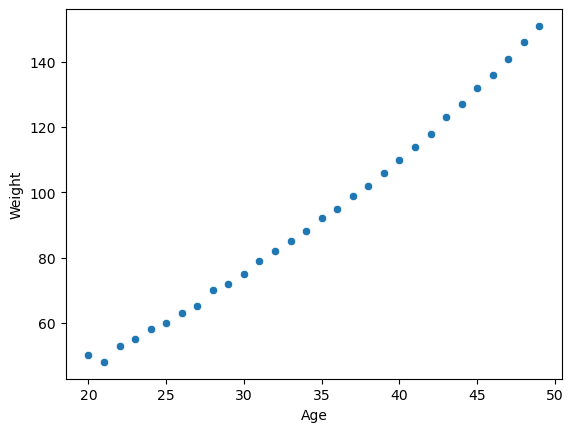

In [64]:
sns.scatterplot(data=df,x="Age",y="Weight")

<Axes: >

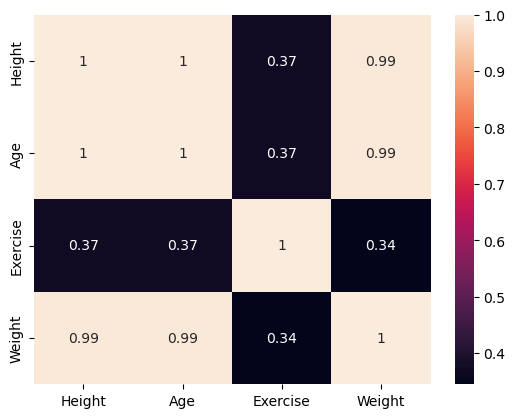

In [65]:
corr=df.corr()
sns.heatmap(corr,annot=True)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,

X=df.drop("Weight",axis=1)
y=df["Weight"]

X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

pipeline=Pipeline([
    ("poly",PolynomialFeatures(degree=2,include_bias=False)),
    ("lr",LinearRegression())
])

pipeline.fit(X_train,y_train)

y_pred=pipeline.predict(X_test)

print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.9994016440971134
0.39466558094561416


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

cv=cross_val_score(LinearRegression(),X,y,cv=5,n_jobs=-1)


cv.fit(X_train,y_train)
y_pred=cv.predict(X_test)

print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

AttributeError: 'numpy.ndarray' object has no attribute 'fit'

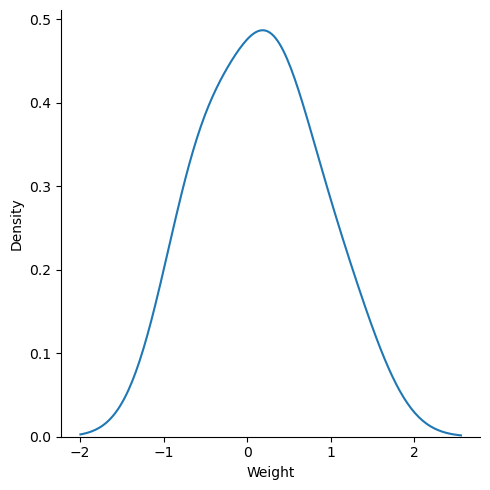

In [68]:
residual=y_test-y_pred

sns.displot(residual,kind='kde')

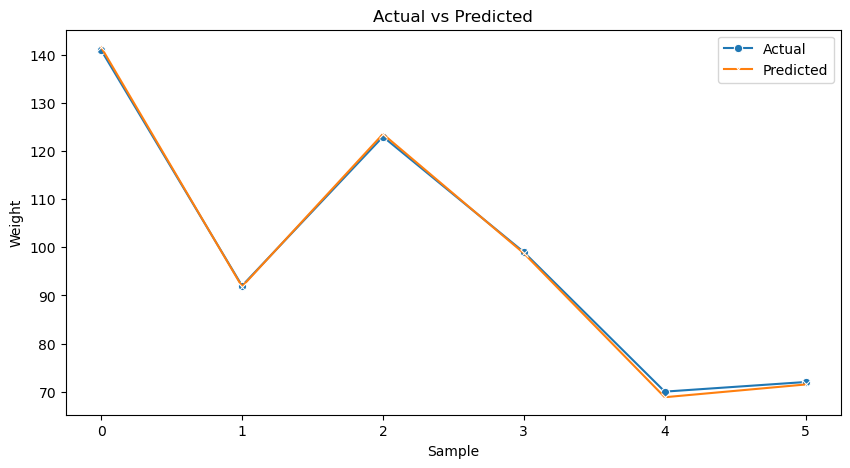

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.lineplot(x=range(len(y_test)), y=y_test.values,
             marker="o", label="Actual")

sns.lineplot(x=range(len(y_pred)), y=y_pred,
             marker="x", label="Predicted")

plt.xlabel("Sample")
plt.ylabel("Weight")
plt.title("Actual vs Predicted")
plt.legend()

plt.show()

In [70]:
y_test

27    141
15     92
23    123
17     99
8      70
9      72
Name: Weight, dtype: int64

In [71]:
y_pred

array([141.59899238,  91.83604458, 123.55334785,  98.75531617,
        68.83650276,  71.4876228 ])